In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.preprocessing  import StandardScaler

from pathlib import Path

In [6]:
path = Path.cwd().parent / 'data' / 'features' / 'features.csv'

df = pd.read_csv(path)
df

,pc_indicador_alfabetizacao,vl_proficiencia_media,vl_proficiencia_mediana,qt_alunos_avaliados,nu_serie,qtd_fam_pobreza,qtd_fam_baixa_renda,qtd_fam_ate_meio_sm,qtd_fam_renda_zero,taxa_atualizacao_geral_pct,...,pct_urbana,pct_rural,ano_2024,ds_rede_municipal,ds_rede_privada,nome_regiao_nordeste,nome_regiao_norte,nome_regiao_sudeste,nome_regiao_sul,uf_freq
0,0.4898,737.60,734.01,49,2,1032,307,1339,560,0.7553,...,0.7273,0.2727,0,1,0,0,0,1,0,0.175485
1,0.5718,747.21,751.72,376,2,1343,987,2330,487,0.7099,...,0.7714,0.2286,0,1,0,0,0,1,0,0.175485
2,0.8706,791.68,795.49,85,2,288,211,499,151,0.5359,...,1.0000,0.0000,0,1,0,0,0,1,0,0.175485
3,0.4440,736.56,737.62,268,2,3194,1618,4812,2053,0.7108,...,0.9737,0.0263,0,1,0,0,0,1,0,0.175485
4,0.3791,730.09,728.07,277,2,4477,924,5401,93,0.8051,...,0.3457,0.6543,0,1,0,0,0,1,0,0.175485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12412,0.6838,756.16,762.64,136,2,18823,5105,23928,147,0.8569,...,0.4174,0.5826,1,0,0,1,0,0,0,0.015624
12413,0.3681,718.33,716.52,144,2,6542,1654,8196,20,0.7740,...,0.8065,0.1935,0,0,0,1,0,0,0,0.015624
12414,0.7955,763.39,768.68,44,2,2857,1972,4829,851,0.6945,...,0.4247,0.5753,0,0,0,0,0,1,0,0.017315
12415,0.7143,762.45,764.47,35,2,1870,1454,3324,243,0.7392,...,0.5938,0.4062,0,0,0,0,0,1,0,0.017315


In [7]:
df["atingiu_meta"] = (
    df["pc_indicador_alfabetizacao"] >= 0.80
).astype(int)

In [8]:
X = df[['vl_proficiencia_media','vl_proficiencia_mediana','qt_alunos_avaliados','nu_serie','qtd_fam_pobreza','qtd_fam_baixa_renda','qtd_fam_ate_meio_sm','qtd_fam_renda_zero','taxa_atualizacao_geral_pct','taxa_atualizacao_ate_meio_sm_pct','qtd_escolas','pct_urbana','pct_rural','ano_2024','ds_rede_municipal','ds_rede_privada','nome_regiao_nordeste','nome_regiao_norte','nome_regiao_sudeste','nome_regiao_sul','uf_freq']] 
y = df['atingiu_meta']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Treino:',X_train.shape)
print('Teste:', X_test.shape)

Treino: (9933, 21)
Teste: (2484, 21)


In [10]:
tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train,y_train)

pred_tree = tree.predict(X_test)

y_proba_tree = tree.predict_proba(X_test)[:, 1]

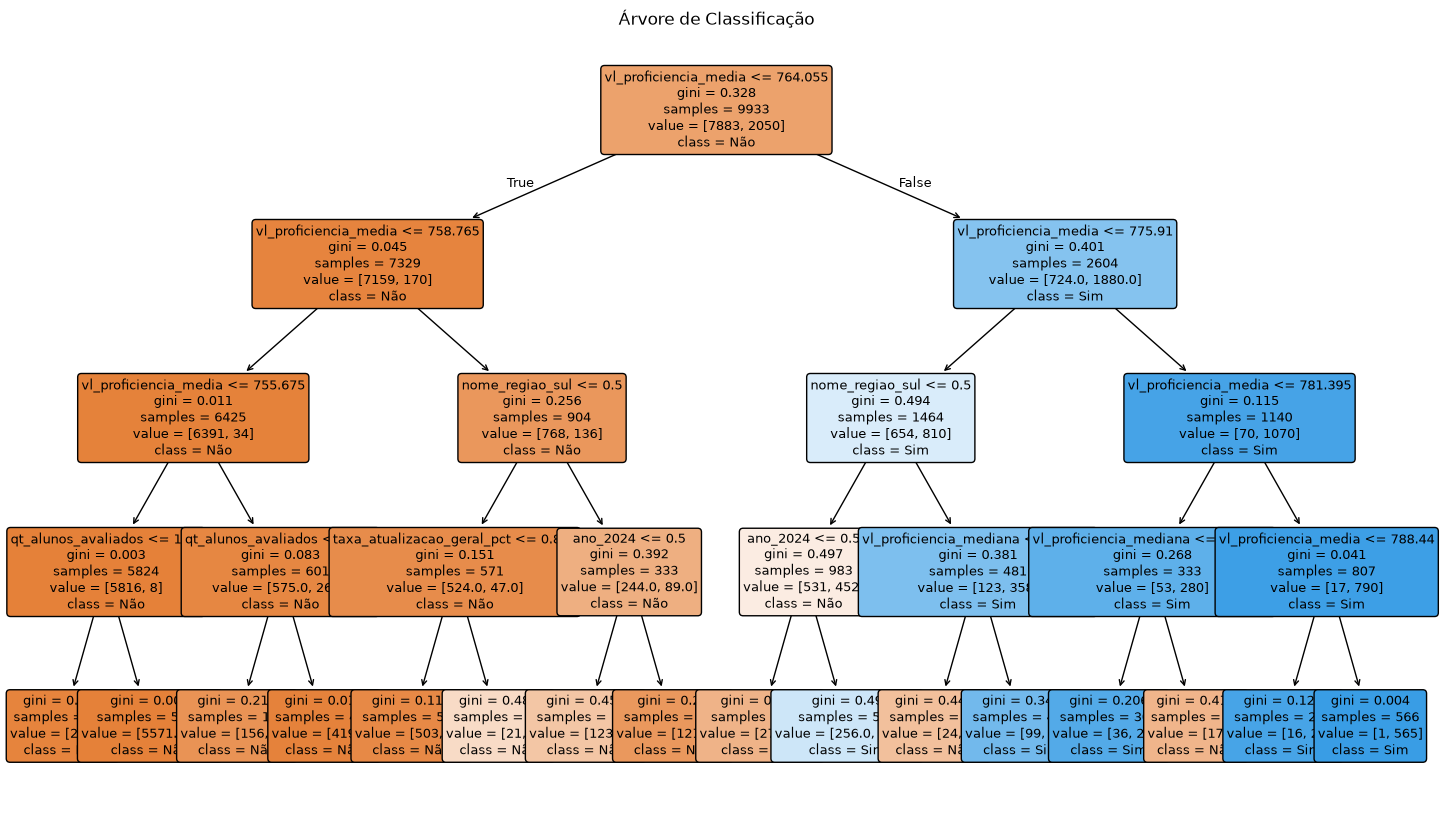

In [11]:
plt.figure(figsize=(18,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['Não','Sim'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title('Árvore de Classificação')
plt.show()

In [12]:
acc_tree = accuracy_score(y_test, pred_tree
)

print('Acurácia:', acc_tree)

Acurácia: 0.9210950080515298


In [13]:
print(df['atingiu_meta'].value_counts())

print("\nProporção:")
print(df['atingiu_meta'].value_counts(normalize=True))

atingiu_meta
0    9873
1    2544
Name: count, dtype: int64

Proporção:
atingiu_meta
0    0.79512
1    0.20488
Name: proportion, dtype: float64


In [14]:
cm_tree = confusion_matrix(y_test, pred_tree)

print(cm_tree)

[[1857  133]
 [  63  431]]


In [15]:
precision_tree = precision_score(y_test, pred_tree)

print("Precision:", precision_tree)

Precision: 0.7641843971631206


In [16]:
recall_tree = recall_score(y_test, pred_tree)

print("Recall:", recall_tree)

Recall: 0.8724696356275303


In [17]:
f1_tree = f1_score(y_test, pred_tree)

print("F1:", f1_tree)

F1: 0.8147448015122873


In [18]:
print(classification_report(y_test, pred_tree))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1990
           1       0.76      0.87      0.81       494

    accuracy                           0.92      2484
   macro avg       0.87      0.90      0.88      2484
weighted avg       0.93      0.92      0.92      2484



In [19]:
y_proba_tree = tree.predict_proba(X_test)[:, 1]

auc_tree = roc_auc_score(y_test, y_proba_tree)

print("ROC-AUC:", auc_tree)

ROC-AUC: 0.9700760889467582


In [20]:
feature_importance_tree = pd.DataFrame({
    'feature': X.columns,
    'importance': tree.feature_importances_
})

feature_importance_tree = feature_importance_tree.sort_values(
    'importance',
    ascending=False
)

print(feature_importance_tree)

                             feature  importance
0              vl_proficiencia_media    0.932767
19                   nome_regiao_sul    0.029436
13                          ano_2024    0.019789
1            vl_proficiencia_mediana    0.012693
8         taxa_atualizacao_geral_pct    0.003794
2                qt_alunos_avaliados    0.001521
3                           nu_serie    0.000000
4                    qtd_fam_pobreza    0.000000
5                qtd_fam_baixa_renda    0.000000
9   taxa_atualizacao_ate_meio_sm_pct    0.000000
10                       qtd_escolas    0.000000
6                qtd_fam_ate_meio_sm    0.000000
7                 qtd_fam_renda_zero    0.000000
12                         pct_rural    0.000000
11                        pct_urbana    0.000000
15                   ds_rede_privada    0.000000
14                 ds_rede_municipal    0.000000
16              nome_regiao_nordeste    0.000000
17                 nome_regiao_norte    0.000000
18               nom